In [2]:
import pandas as pd

## Tempature:

Tempature is a common feature across the existing research on PM2.5 prediction. Tempature was found to play the most dominant role in PM2.5 prediction for (Paper: Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons).

It has a causual link to Pollutant dispersion so it contains valuable information about hw PM2.5 behaves in the atmosphere. Multiple studies highlight 'tempature inversions` during cold winter months as a key factor in PM2.5 pollution events, as the cold air gets trapped under a layer of warmer air, preventing the dispersion of pollutants and leading to higher concentrations of PM2.5 near the ground.

Futhermore, tempature acts as a 'temporal anchor' helping stabilize deep learning models over extended forecast horizons. This is because tempature is a relatively stable and predictable feature, which can help the model learn the underlying patterns in the data and make more accurate predictions over longer time periods. Making it especially important for our use case, as we are predicting PM2.5 levels over long time horizon.

Most papers, sensibly, scale and normalize tempature before feeding it into the model, as this helps the model learn more effectively and prevents it from being biased towards certain ranges of tempature values.

### Ensure National scale:

We will gather the average tempature across everywhere where stations are present, even if they weren't reporting on a given day. This is to ensure that our tempature feature is representative of the entire country and not just a few stations, which could lead to biased predictions. The reasoning for not taking a pure national average is that we want to maintain correlation with the PM2.5 stations, which are not evenly distributed across the country. By averaging only over the regions where stations are at some point present, we ensure that our tempature feature is representative of the entire country while protecting the correlation with the PM2.5 stations, which is important for our model's performance.

#### References:

1. Dominant Predictive Weight

The finding that temperature received the highest attention weight (0.2654) in a Transformer-LSTM model, proving its dominant role in capturing seasonal and diurnal influences, is from:

Zeng, L., Dong, R., Yuan, M., Jing, L., & Jiao, S. (2026). Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons. iScience, 29, 114770.

2. Causal Link to Pollutant Dispersion

The conclusion that meteorological factors like temperature and wind exert a direct causal influence on short-term pollutant dispersion, accumulation, and atmospheric stability is supported by:
Zeng, L., et al. (2026)..
Naeini, A. A., Naeini, A. A., Mohammadi, F. K., & Ghaffarpasand, O. Long-Term PM2.5 Forecasting Using a DTW-Enhanced CNN-GRU Model..

3. Predicting Temperature Inversions

The observation that temperature inversions restrict vertical mixing and trap PM2.5 close to the ground—causing severe, short-lived pollution peaks—is highlighted in:

Wood, D. A. (2024). Trend-attribute forecasting of hourly PM2.5 trends in fifteen cities of Central England applying optimized machine learning feature selection. Journal of Environmental Management, 356, 120561.

Naeini, A. A., et al..

Zeng, L., et al. (2026)..

4. Stabilizing Long-Term Forecasts
The concept of using auxiliary meteorological features like temperature as "temporal anchors" to prevent model degradation and stabilize long-term predictions (e.g., 10-day forecasts) is discussed in:
Naeini, A. A., et al..

5. Scaling and Normalizing Temperature Data (Note)

The necessity of using Min-Max scaling or normalization on features like temperature so their measurement scales do not bias the neural networks is detailed in:

Patel, P., Patel, S., Shah, K., Desai, K., Patel, S., Shah, M., & Patel, S. (2025). A systematic study on PM2.5 and PM10 concentration prediction in air pollution using machine learning and deep learning model. Environmental Chemistry and Ecotoxicology, 7, 1401–1415.

Naeini, A. A., et al..

Wood, D. A. (2024)..

#### Met Office Data

The met office provides a large amount of historical weather data, including temperature readings from various stations across the UK. We will use this data to calculate the average temperature for each day, ensuring that our temperature feature is representative of the entire country.

With the min and max data that the met office provide, we can calculate the average temperature for each day by taking the mean of the maximum and minimum temperatures.

We will also take the min and max tempature readings for each day, as these could provide additional information about the range of temperatures experienced on a given day, which could be relevant for PM2.5 prediction.

tasmax: https://data.ceda.ac.uk/badc/ukmo-hadobs/data/insitu/MOHC/HadOBS/HadUK-Grid/v1.3.1.ceda/region/tasmax/day/v20250415/

tasmin: https://data.ceda.ac.uk/badc/ukmo-hadobs/data/insitu/MOHC/HadOBS/HadUK-Grid/v1.3.1.ceda/region/tasmin/day/v20250415/

Dataset catalogue record: https://catalogue.ceda.ac.uk/uuid/896792be61a241a88bb668b5adfdb353/

HadUK-Grid Climate Observations by Administrative Regions over the UK, v1.3.1.ceda (1836-2024)


In [3]:
TEMPERATURE_CSV = '../data/uk_temperature_by_region.csv'
temperature_df = pd.read_csv(TEMPERATURE_CSV, parse_dates=['date'])
temperature_df.head()

,date,region,tasmax_c,tasmin_c,source,frequency
0,2016-01-01,Channel Islands,NaN,NaN,ceda_hadukgrid_region,daily
1,2016-01-01,East Midlands,8.18504,-0.67849,ceda_hadukgrid_region,daily
2,2016-01-01,East Scotland,5.92110,-1.21612,ceda_hadukgrid_region,daily
3,2016-01-01,East of England,8.98019,-0.49313,ceda_hadukgrid_region,daily
4,2016-01-01,Isle of Man,8.04298,2.91936,ceda_hadukgrid_region,daily


In [4]:
station_to_region = {
    'Auchencorth Moss': 'Scotland',
    'Inverness': 'Scotland',
    'Bournemouth': 'South West',
    'Brighton Preston Park': 'South East',
    'Chilbolton Observatory': 'South East',
    'London Marylebone Road': 'London',
    'London N. Kensington': 'London',
    'London Westminster': 'London',
    'Northampton Kingsthorpe': 'East Midlands',
    'Wrexham': 'Wales'
}

In [5]:
# Map station regions to the region names used in the temperature dataset.
region_name_map = {
    'Scotland': ['East Scotland', 'North Scotland', 'West Scotland'],
    'South West': ['South West England'],
    'South East': ['South East England'],
    'London': ['London'],
    'East Midlands': ['East Midlands'],
    'Wales': ['Wales']
}

# Keep only temperature rows that have a matching PM station record by date + region.
PM25_STATION_CSV = '../data/splits/per_station_with_split.csv'
pm_station_df = pd.read_csv(PM25_STATION_CSV, parse_dates=['date'])

# convert the station regions to the temperature dataset region names, which may be multiple for a single station region and store in temp_regions column
pm_station_df['temp_regions'] = pm_station_df['region'].map(
    lambda r: region_name_map.get(r, [r])
)

pm_date_region = (
    pm_station_df[['date', 'temp_regions']]
    .explode('temp_regions')
    .rename(columns={'temp_regions': 'region'})
    .drop_duplicates()
)

# merge temperature data with PM station data on date and region to keep only matched records
matched_region = ( 
    temperature_df
    .merge(pm_date_region, on=['date', 'region'], how='inner')  # inner keeps only matched rows.
    .copy()
)

# create an average temperature column by taking the mean of the max and min temperature columns
matched_region['temp_mean_c'] = matched_region[['tasmax_c', 'tasmin_c']].mean(axis=1)

# add a new column to the matched_region dataframe that contains the average temperature for each day across all regions
daily_temperature_avg = (
    matched_region.groupby('date', as_index=False)['temp_mean_c']
    .mean()
    .rename(columns={'temp_mean_c': 'temperature_avg_station_regions_c'})
)

print('Matched regions:', sorted(pm_date_region['region'].unique()))
print('Temperature rows after dropping unmatched records:', len(matched_region))
daily_temperature_avg.head()

Matched regions: ['East Midlands', 'East Scotland', 'London', 'North Scotland', 'South East England', 'South West England', 'Wales', 'West Scotland']
Temperature rows after dropping unmatched records: 8016


,date,temperature_avg_station_regions_c
0,2016-01-01,3.988064
1,2016-01-02,5.580601
2,2016-01-03,6.375886
3,2016-01-04,6.135536
4,2016-01-05,5.856228


In [6]:
daily_temperature_features = (
    matched_region.groupby('date', as_index=False)[['tasmax_c', 'tasmin_c']]
    .agg({'tasmax_c': 'max', 'tasmin_c': 'min'}) # get the max and min temperature for each date across all matched regions
    .rename(columns={'tasmax_c': 'temperature_max_station_regions_c', 'tasmin_c': 'temperature_min_station_regions_c'})
)

daily_temperature_features = daily_temperature_features.merge(
    daily_temperature_avg, on='date', how='left'
)

daily_temperature_features.head()

,date,temperature_max_station_regions_c,temperature_min_station_regions_c,temperature_avg_station_regions_c
0,2016-01-01,10.24023,-1.24204,3.988064
1,2016-01-02,10.87211,-0.26949,5.580601
2,2016-01-03,10.06486,4.25325,6.375886
3,2016-01-04,10.38715,3.31853,6.135536
4,2016-01-05,10.09688,2.28312,5.856228


In [7]:
daily_temperature_features.isnull().sum()

date                                 0
temperature_max_station_regions_c    0
temperature_min_station_regions_c    0
temperature_avg_station_regions_c    0
dtype: int64

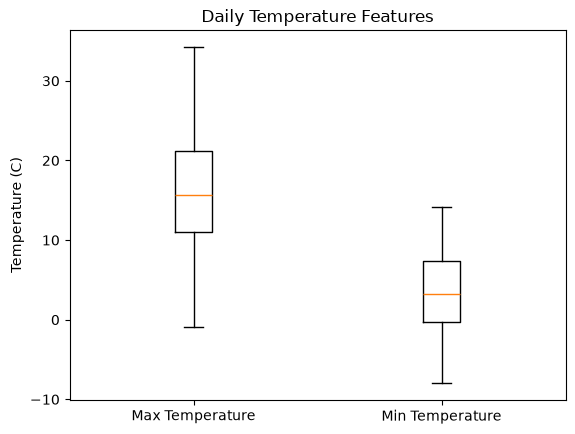

In [8]:
#box plot of the daily temperature features
import matplotlib.pyplot as plt
plt.boxplot([daily_temperature_features['temperature_max_station_regions_c'],
             daily_temperature_features['temperature_min_station_regions_c']])
plt.xticks([1, 2], ['Max Temperature', 'Min Temperature'])
plt.ylabel('Temperature (C)')
plt.title('Daily Temperature Features')
plt.show()

In [9]:
#check for outliers in the daily temperature features (anything above 50C or below -20C)
outliers = daily_temperature_features[(daily_temperature_features['temperature_max_station_regions_c'] > 50) | 
                                   (daily_temperature_features['temperature_min_station_regions_c'] < -20)]
print('Outliers in daily temperature features:', len(outliers))
outliers.head()


Outliers in daily temperature features: 0


,date,temperature_max_station_regions_c,temperature_min_station_regions_c,temperature_avg_station_regions_c


## Wind:

